# Grad-CAM Code Kata

This notebook demonstrates Grad-CAM with a CPU-friendly pretrained MobileNetV2 classifier.

The goal is to answer a practical debugging question: **which image regions influenced the model's class prediction most?**

## 1. Imports

The first run may need to download MobileNetV2 ImageNet weights through `torchvision`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

torch.set_grad_enabled(True)
device = torch.device("cpu")
device

device(type='cpu')

## 2. Load An Image

Swap `image_path` with any local image to make the demo interactive.

In [2]:
cwd = Path.cwd()
notebook_dir = cwd if (cwd / "grad_cam.py").exists() else cwd / "grad-cam-code-kata"
# image_path = notebook_dir / "sample_images" / "idea-wall-short-v2.png"
image_path = notebook_dir / "sample_images" / "updated-zoom-bg-2.png"

image = Image.open(image_path).convert("RGB")
image.size

(1086, 1448)

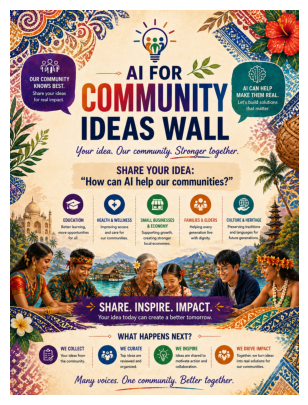

In [3]:
plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.axis("off");

## 3. Load A Pretrained Classifier

MobileNetV2 is small enough for a CPU demo and still has convolutional feature maps we can inspect.

If the machine cannot download model weights, copy `mobilenet_v2-7ebf99e0.pth` into `model_checkpoints/` and set `local_weights_path` below.

In [4]:
weights = MobileNet_V2_Weights.DEFAULT

# Leave as None to let torchvision download/use its cached checkpoint.
# For offline use, set this to: notebook_dir / "model_checkpoints" / "mobilenet_v2-7ebf99e0.pth"
local_weights_path = None

if local_weights_path is None:
    model = mobilenet_v2(weights=weights).to(device)
else:
    model = mobilenet_v2(weights=None).to(device)
    checkpoint = torch.load(local_weights_path, map_location=device)
    model.load_state_dict(checkpoint)
model.eval()

preprocess = weights.transforms()
input_tensor = preprocess(image).unsqueeze(0).to(device)
input_tensor.shape

torch.Size([1, 3, 224, 224])

## 4. Capture Activations And Gradients

Grad-CAM needs two signals from a convolution layer:

- **Activations** from the forward pass
- **Gradients** from the backward pass for a target class score

In [5]:
activations = None
gradients = None

def save_activations(_module, _inputs, output):
    global activations
    activations = output.detach()

def save_gradients(_module, _grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()

target_layer = model.features[-1]
forward_handle = target_layer.register_forward_hook(save_activations)
backward_handle = target_layer.register_full_backward_hook(save_gradients)

## 5. Predict A Class

By default, we explain the top prediction. You can set `target_class_index` manually to explain a different ImageNet class.

In [6]:
target_class_index = None

model.zero_grad(set_to_none=True)
logits = model(input_tensor)
probabilities = torch.softmax(logits, dim=1)

if target_class_index is None:
    target_class_index = int(probabilities.argmax(dim=1).item())

target_label = weights.meta["categories"][target_class_index]
target_confidence = float(probabilities[0, target_class_index].item())

target_class_index, target_label, target_confidence

(917, 'comic book', 0.1352584809064865)

## 6. Build The Grad-CAM Heatmap

The key idea: gradients tell us how important each feature channel was for the selected class.

In [7]:
score = logits[:, target_class_index].sum()
score.backward()

channel_weights = gradients.mean(dim=(2, 3), keepdim=True)
cam = (channel_weights * activations).sum(dim=1, keepdim=True)
cam = F.relu(cam)
cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
heatmap = cam.squeeze().cpu().numpy()

heatmap = heatmap - heatmap.min()
if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()

activations.shape, gradients.shape, heatmap.shape

(torch.Size([1, 1280, 7, 7]), torch.Size([1, 1280, 7, 7]), (224, 224))

## 7. Overlay The Heatmap

The red/yellow regions contributed most strongly to the selected class score.

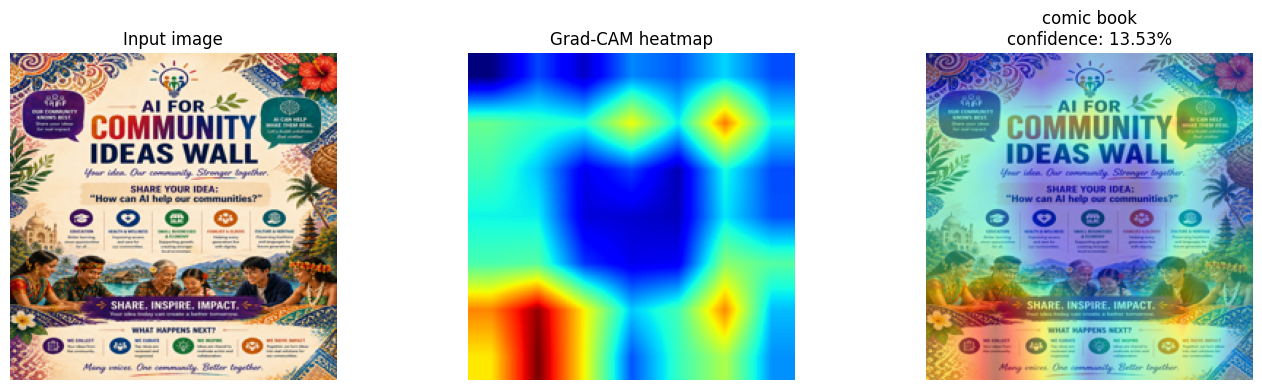

In [8]:
def overlay_heatmap(original_image, heatmap, alpha=0.45):
    resized = original_image.resize((heatmap.shape[1], heatmap.shape[0]))
    image_array = np.asarray(resized).astype(np.float32) / 255.0
    colored_heatmap = plt.get_cmap("jet")(heatmap)[..., :3]
    overlay = (1 - alpha) * image_array + alpha * colored_heatmap
    return resized, np.clip(overlay, 0, 1)

resized_image, overlay = overlay_heatmap(image, heatmap)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(resized_image)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM heatmap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"{target_label}\nconfidence: {target_confidence:.2%}")
axes[2].axis("off")

plt.tight_layout();

## 8. Save The Demo Result

In [9]:
output_dir = notebook_dir / "outputs"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "grad_cam_notebook_result.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
output_path

PosixPath('/Users/xiaoyanzhuo/Documents/grad-cam-code-kata/outputs/grad_cam_notebook_result.png')

## Try These Kata Changes

- Replace `image_path` with another image.
- Change `target_class_index` and compare how the heatmap moves.
- Try an out-of-distribution image, such as a UI screenshot or diagram.
- Swap MobileNetV2 for ResNet18: import `ResNet18_Weights, resnet18`, set `weights = ResNet18_Weights.DEFAULT`, build `model = resnet18(...)`, and use `target_layer = model.layer4[-1]`.
- If using a local checkpoint, make sure the checkpoint architecture matches the model builder.
- Add blur, crop, or brightness changes before preprocessing and compare the explanation.

In [10]:
forward_handle.remove()
backward_handle.remove()